In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config, volatility

# target_volatility = 'Sq_Log_Return'
target_volatility = 'Vol_EGARCH' # or 'Vol_GARCH'

macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
# macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-09 15:07:10 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)

    # Generate GARCH Volatility (The clean "Panic" signal)
    garch_df = volatility.generate_expanding_garch(stat_df)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(garch_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=5, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-09 15:07:10 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-09 15:07:10 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK


2026-06-09 15:07:12 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...
2026-06-09 15:07:24 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6208, 14)
2026-06-09 15:07:24 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-09 15:07:25 - src.features - INFO - Calculating Autoregressive Macro Surprises...



--- Granger Causality: Macro -> XLK ---
[CPI_Surprise]
  Lag 1: p-value = 0.6645 
  Lag 2: p-value = 0.9932 
  Lag 3: p-value = 0.9916 
  Lag 4: p-value = 0.9938 
  Lag 5: p-value = 0.9973 
[PPI_Surprise]
  Lag 1: p-value = 0.5007 
  Lag 2: p-value = 0.9406 
  Lag 3: p-value = 0.9549 
  Lag 4: p-value = 0.9916 
  Lag 5: p-value = 0.9937 
[FedFunds_Diff]
  Lag 1: p-value = 0.4895 
  Lag 2: p-value = 0.4393 
  Lag 3: p-value = 0.3602 
  Lag 4: p-value = 0.2162 
  Lag 5: p-value = 0.3160 

Fitting VAR Model for XLK...

LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -11.65      -11.65   8.719e-06      -11.65
1      -18.02      -18.00   1.489e-08      -18.01
2      -19.09      -19.05   5.127e-09      -19.08
3      -19.22      -19.16   4.497e-09      -19.20
4      -19.26     -19.19*   4.319e-09      -19.23
5     -19.27*      -19.18  4.275e-09*     -19.24*
----

2026-06-09 15:07:26 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...
2026-06-09 15:07:37 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6208, 14)
2026-06-09 15:07:37 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-09 15:07:37 - src.features - INFO - Calculating Autoregressive Macro Surprises...



--- Granger Causality: Macro -> XLE ---
[CPI_Surprise]
  Lag 1: p-value = 0.0246 **
  Lag 2: p-value = 0.0828 *
  Lag 3: p-value = 0.0265 **
  Lag 4: p-value = 0.0166 **
  Lag 5: p-value = 0.0123 **
[PPI_Surprise]
  Lag 1: p-value = 0.0016 ***
  Lag 2: p-value = 0.0001 ***
  Lag 3: p-value = 0.0014 ***
  Lag 4: p-value = 0.0000 ***
  Lag 5: p-value = 0.0001 ***
[FedFunds_Diff]
  Lag 1: p-value = 0.3361 
  Lag 2: p-value = 0.5629 
  Lag 3: p-value = 0.4510 
  Lag 4: p-value = 0.4959 
  Lag 5: p-value = 0.2788 

Fitting VAR Model for XLE...

PROCESSING SECTOR: XLF


2026-06-09 15:07:38 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...
2026-06-09 15:07:49 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6208, 14)
2026-06-09 15:07:49 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-09 15:07:49 - src.features - INFO - Calculating Autoregressive Macro Surprises...



--- Granger Causality: Macro -> XLF ---
[CPI_Surprise]
  Lag 1: p-value = 0.8350 
  Lag 2: p-value = 0.7726 
  Lag 3: p-value = 0.9297 
  Lag 4: p-value = 0.9150 
  Lag 5: p-value = 0.9720 
[PPI_Surprise]
  Lag 1: p-value = 0.5003 
  Lag 2: p-value = 0.9185 
  Lag 3: p-value = 0.9712 
  Lag 4: p-value = 0.9745 
  Lag 5: p-value = 0.9912 
[FedFunds_Diff]
  Lag 1: p-value = 0.9635 
  Lag 2: p-value = 0.8363 
  Lag 3: p-value = 0.9380 
  Lag 4: p-value = 0.9817 
  Lag 5: p-value = 0.7372 

Fitting VAR Model for XLF...

PROCESSING SECTOR: XLV


2026-06-09 15:07:50 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...
2026-06-09 15:08:02 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6208, 14)



--- Granger Causality: Macro -> XLV ---
[CPI_Surprise]
  Lag 1: p-value = 0.5637 
  Lag 2: p-value = 0.9055 
  Lag 3: p-value = 0.9476 
  Lag 4: p-value = 0.9725 
  Lag 5: p-value = 0.9915 
[PPI_Surprise]
  Lag 1: p-value = 0.8567 
  Lag 2: p-value = 0.9597 
  Lag 3: p-value = 0.9936 
  Lag 4: p-value = 0.9971 
  Lag 5: p-value = 0.9961 
[FedFunds_Diff]
  Lag 1: p-value = 0.4711 
  Lag 2: p-value = 0.8098 
  Lag 3: p-value = 0.2185 
  Lag 4: p-value = 0.2972 
  Lag 5: p-value = 0.2553 

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF          \
                    Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   P-Val   
const             0.0018  0.0000  ***  0.0020  0.0000  ***  0.0009     0.0   
L1.CPI_Surprise   0.0005  0.6821      -0.0055  0.0012  *** -0.0002  0.7781   
L1.PPI_Surprise  -0.0001  0.7416       0.0010  0.0452   ** -0.0002  0.5238   
L1.FedFunds_Diff  0.0044  0.3041      -0.0049  0.4080       0.0012  0.7027   
L1.Vol_EGARCH     0.6699  0.0000  ***  0.6778  0.0000  ***  0.7393     0.0   
L2.CPI_Surprise  -0.0005  0.7800       0.0059  0.0114   **  0.0005  0.6884   
L2.PPI_Surprise  -0.0001  0.8845       0.0000  0.9983       0.0003  0.5572   
L2.FedFunds_Diff  0.0027  0.5213      -0.0019  0.7424      -0.0014  0.6606   
L2.Vol_EGARCH     0.4956  0.0000  ***  0.4501  0.0000  ***  0.2389     0.0   
L3.CPI_Surprise  -0.0003  0.8792      -0.0000  0.9889      -0.0002  0.8465   
L3.PPI_Surprise   0.0001  0.9182      -0.0007  0.5199      -0.0001  0.8009   
L3.FedFunds_Diff -0.0058  0.1771      -0.0074  0.2075       0.0003  0.9254   
L3.Vol_EGARCH    -0.4080  0.0000  *** -0.3038  0.0000  *** -0.0971     0.0   
L4.CPI_Surprise   0.0003  0.8596       0.0010  0.6162       0.0003  0.5875   
L4.PPI_Surprise   0.0000  0.9485      -0.0007  0.5154      -0.0001   0.743   
L4.FedFunds_Diff -0.0068  0.1100      -0.0051  0.3884      -0.0007  0.8299   
L4.Vol_EGARCH     0.2860  0.0000  ***  0.2534  0.0000  ***  0.0806     0.0   
L5.CPI_Surprise   0.0000  0.9928       0.0001  0.9324            -       -   
L5.PPI_Surprise   0.0001  0.9228      -0.0008  0.3090            -       -   
L5.FedFunds_Diff  0.0009  0.8323       0.0103  0.0788    *       -       -   
L5.Vol_EGARCH    -0.1207  0.0000  *** -0.1421  0.0000  ***       -       -   

                          XLV               
                  Sig    Coef   P-Val  Sig  
const             ***  0.0011     0.0  ***  
L1.CPI_Surprise       -0.0001  0.8624       
L1.PPI_Surprise          -0.0  0.8066       
L1.FedFunds_Diff      -0.0007   0.775       
L1.Vol_EGARCH     ***  0.7885     0.0  ***  
L2.CPI_Surprise       -0.0002  0.8472       
L2.PPI_Surprise        0.0001  0.8401       
L2.FedFunds_Diff       0.0008   0.719       
L2.Vol_EGARCH     ***   0.212     0.0  ***  
L3.CPI_Surprise        0.0002  0.7187       
L3.PPI_Surprise           0.0  0.9545       
L3.FedFunds_Diff       0.0048  0.0416   **  
L3.Vol_EGARCH     ***  -0.075     0.0  ***  
L4.CPI_Surprise             -       -    -  
L4.PPI_Surprise             -       -    -  
L4.FedFunds_Diff            -       -    -  
L4.Vol_EGARCH     ***       -       -    -  
L5.CPI_Surprise     -       -       -    -  
L5.PPI_Surprise     -       -       -    -  
L5.FedFunds_Diff    -       -       -    -  
L5.Vol_EGARCH       -       -       -    -


VISUAL DIAGNOSTICS: XLK


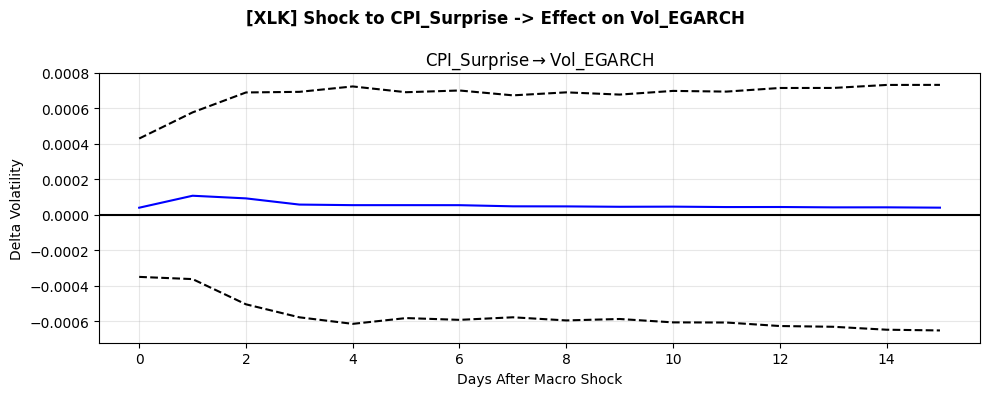

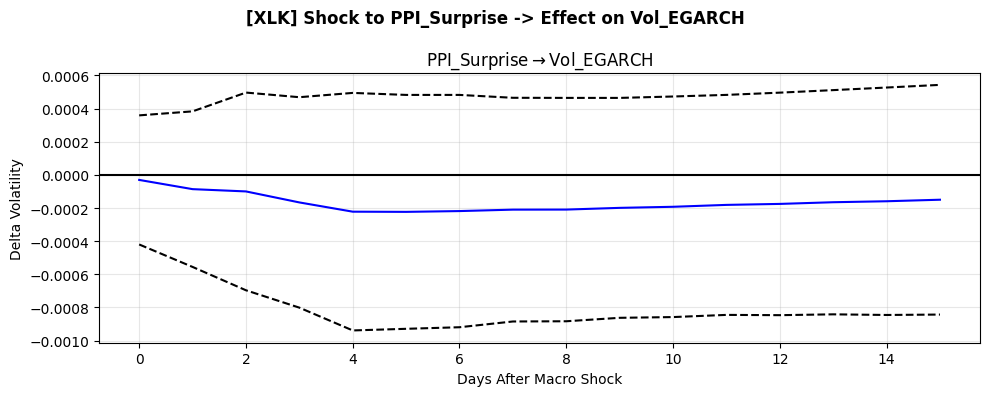

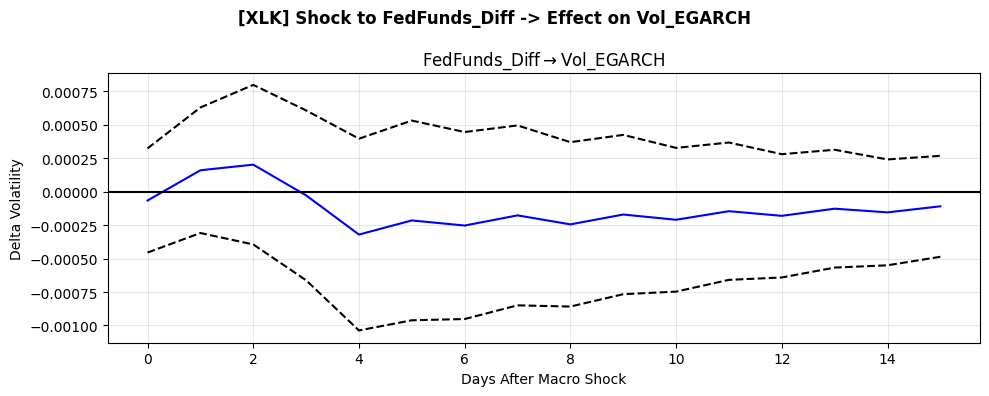

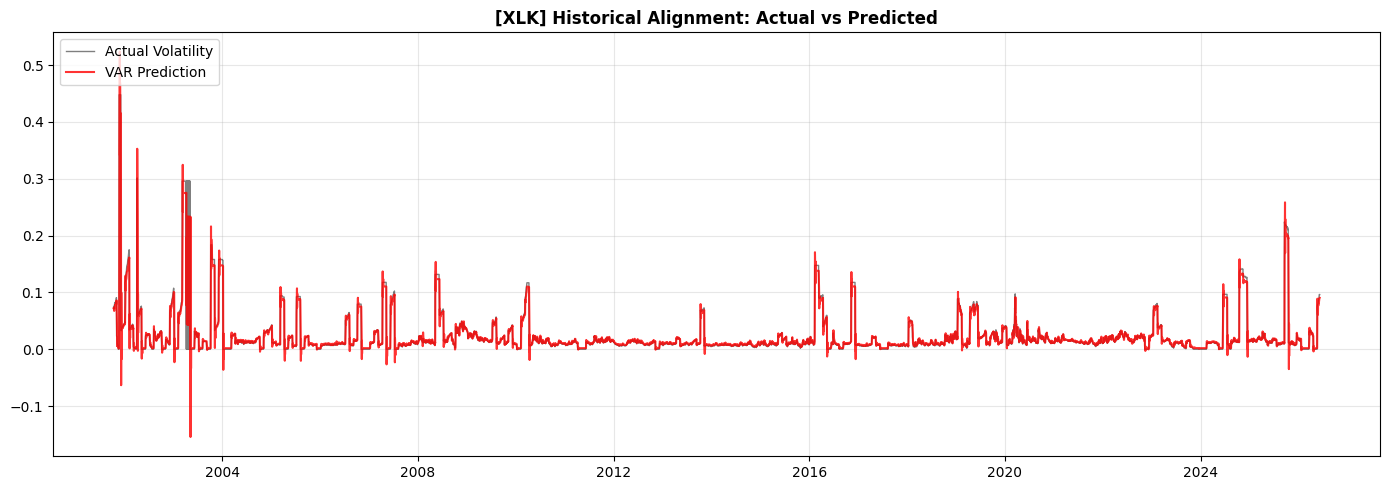


VISUAL DIAGNOSTICS: XLE


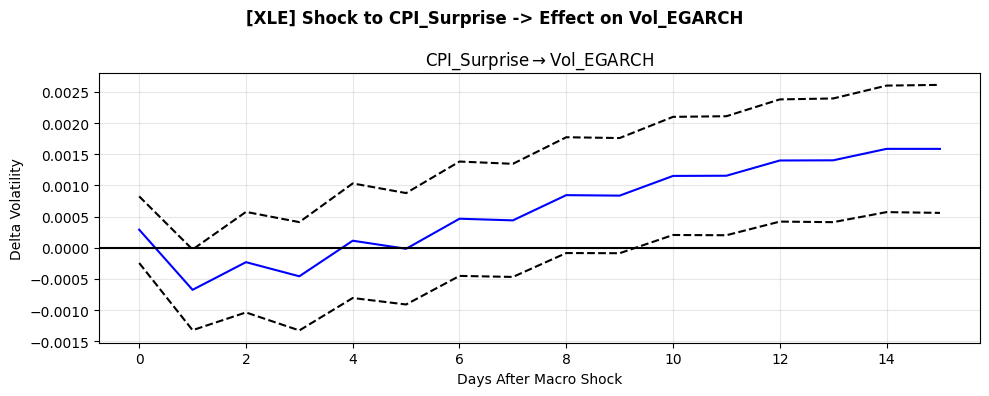

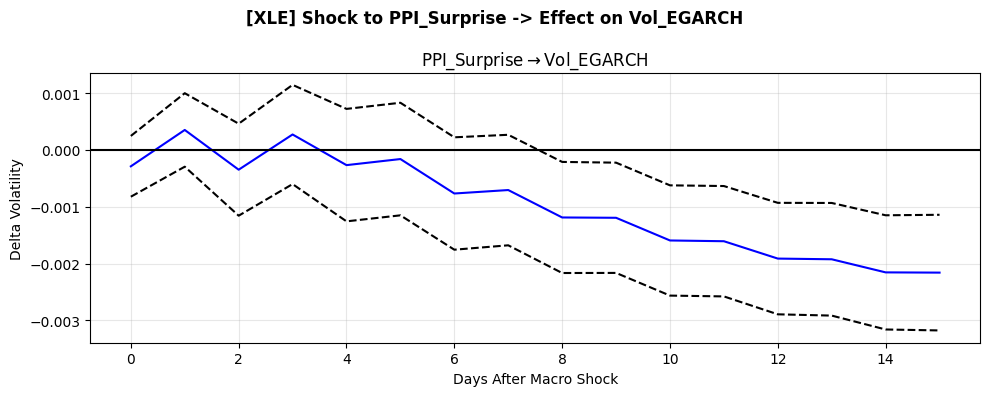

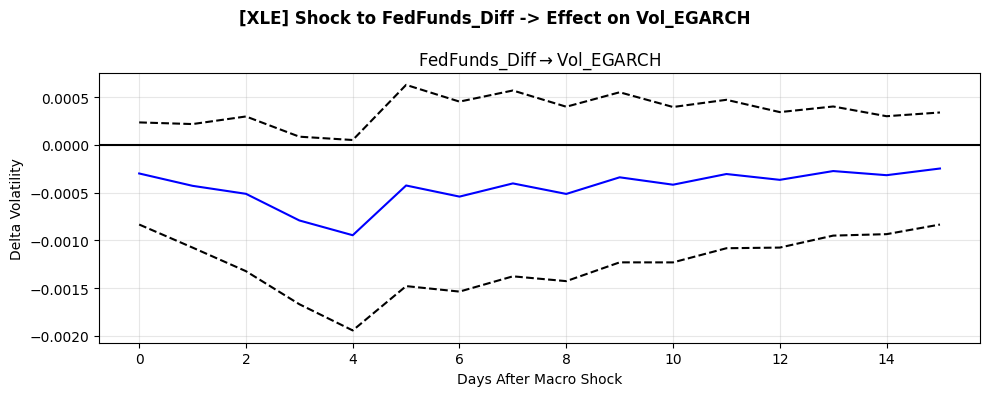

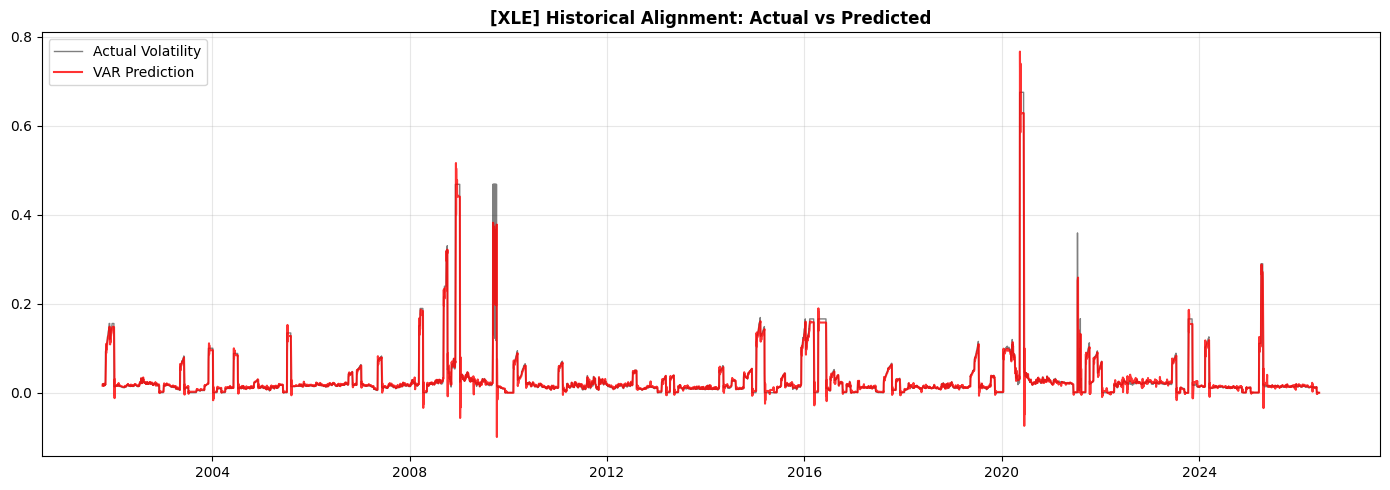


VISUAL DIAGNOSTICS: XLF


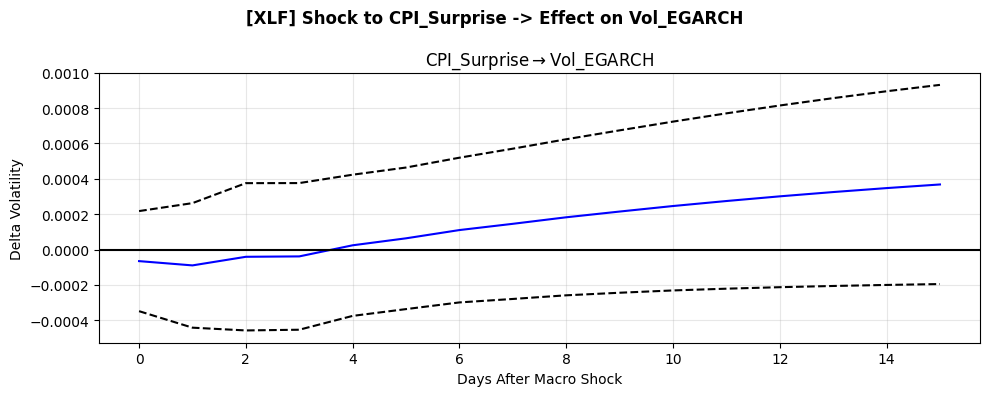

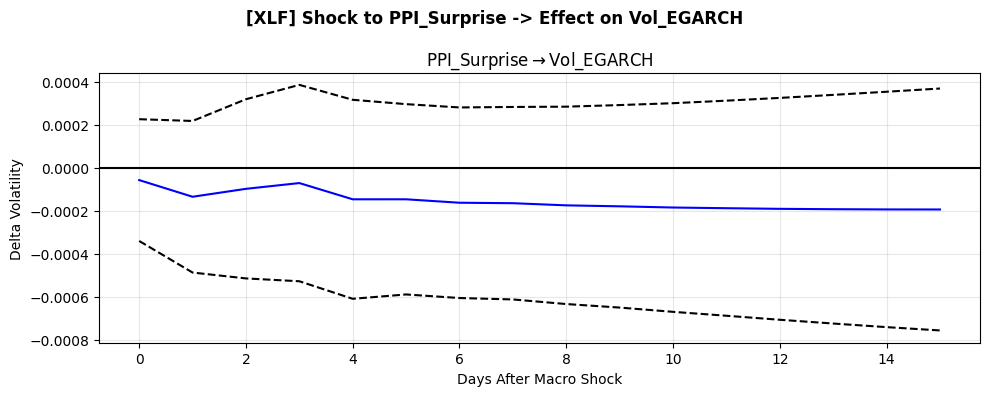

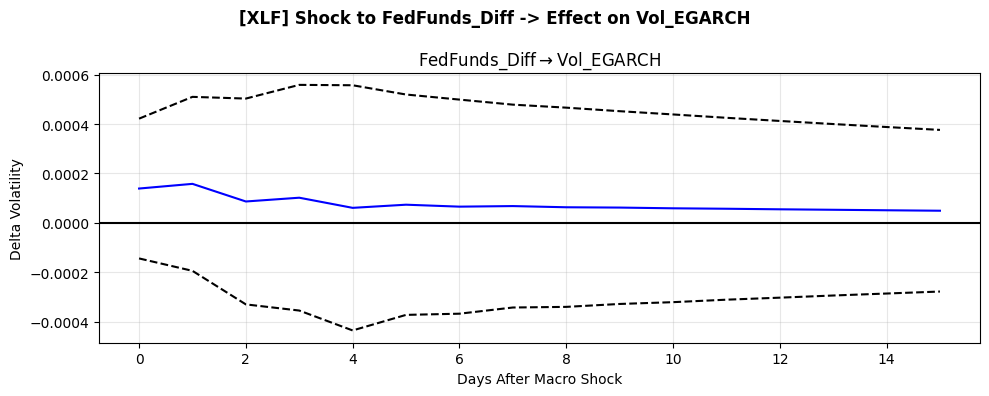

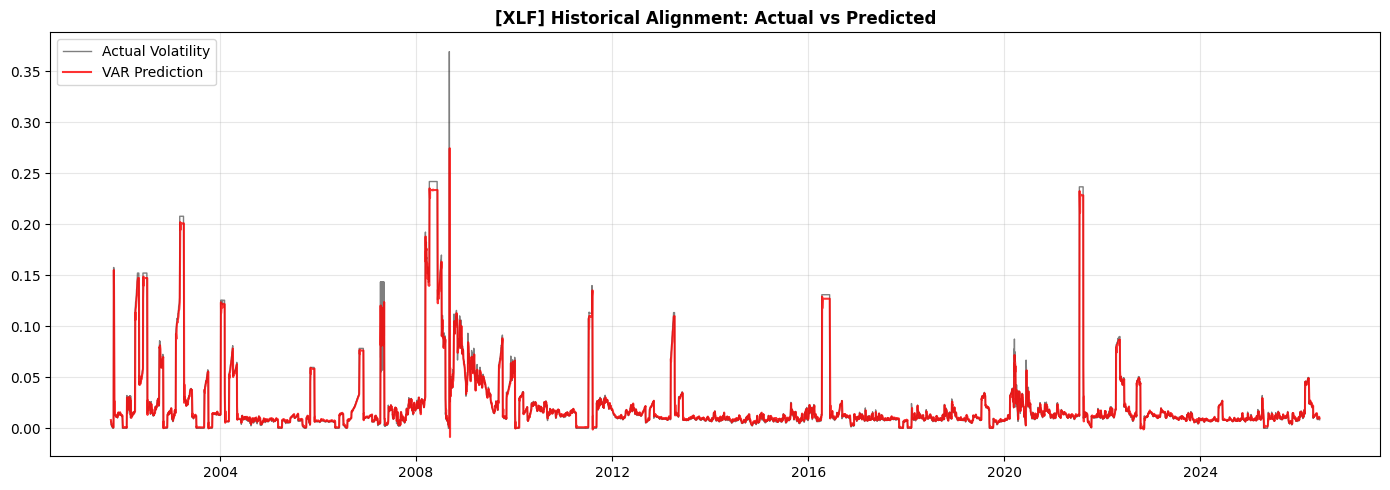


VISUAL DIAGNOSTICS: XLV


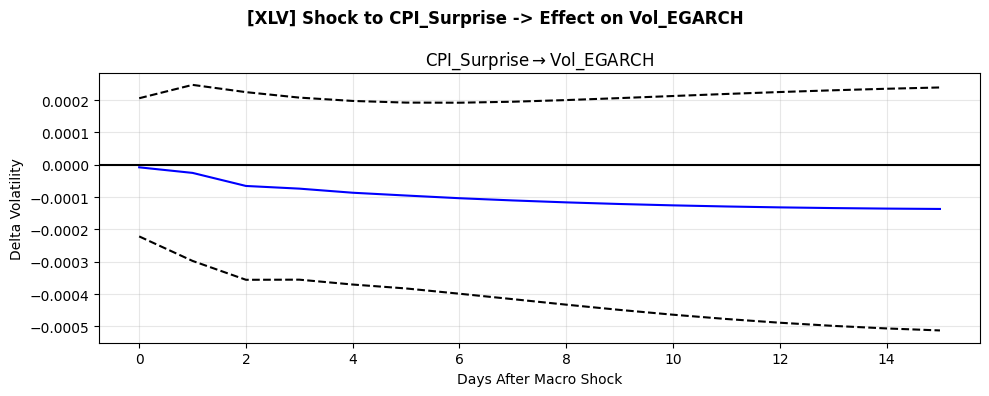

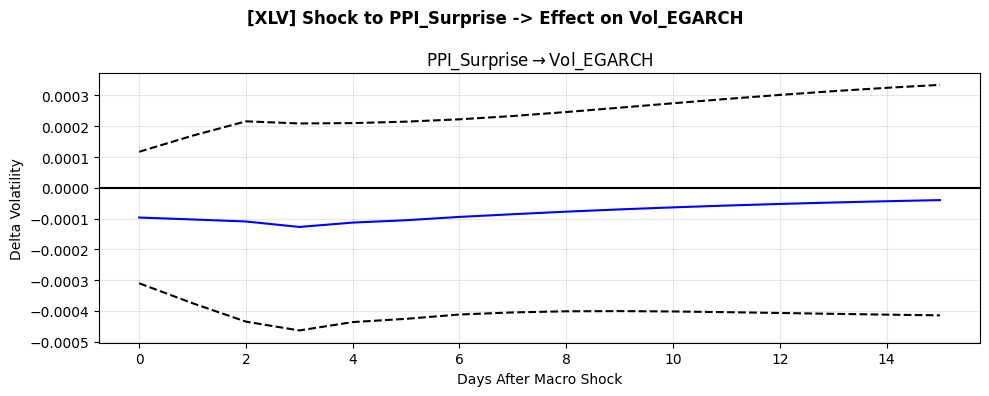

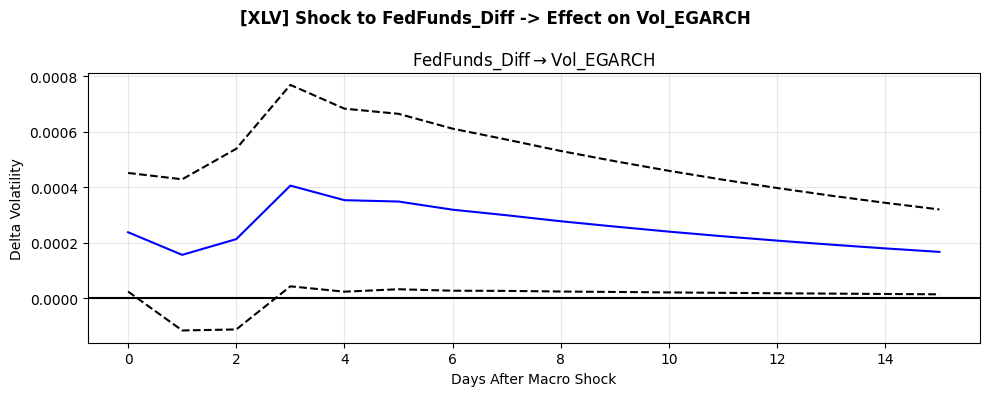

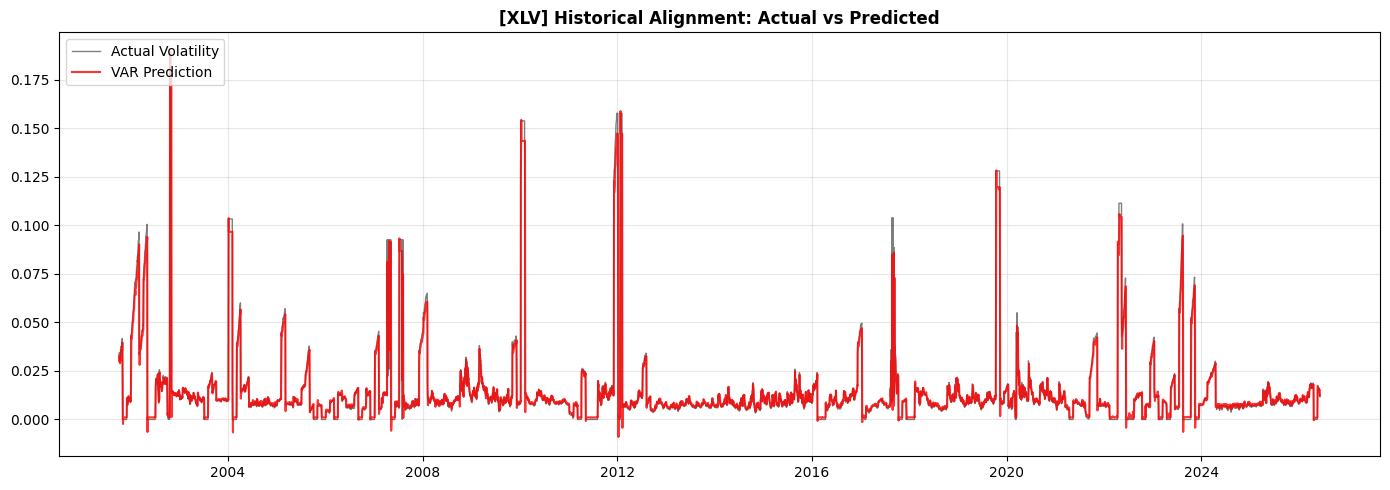

In [4]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
